# SquatTrainer

This notebook implements the full squat posture classification pipeline for the dataset in `Data/train` and `Data/test`.

Important constraint: the current dataset is organized as labeled still images, so the implemented model is a **frame classifier** rather than a temporal video model. The webcam demo therefore predicts posture from each live frame and smooths predictions across recent frames.


## 1. Setup

This cell loads the project-local dependencies from `.deps` and imports the reusable modules used throughout the notebook.


In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
DEPS_DIR = PROJECT_ROOT / ".deps"
CACHE_DIR = PROJECT_ROOT / ".cache"
MPLCONFIGDIR = PROJECT_ROOT / ".mplconfig"
CACHE_DIR.mkdir(exist_ok=True)
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_DIR))
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))
if DEPS_DIR.exists():
    sys.path.insert(0, str(DEPS_DIR))

import json
import random

import matplotlib.pyplot as plt
import torch

from squat_trainer.data import (
    DISPLAY_NAMES,
    SquatImageDataset,
    class_names_from_records,
    scan_split,
    stratified_train_val_split,
    summarize_records,
)
from squat_trainer.inference import load_checkpoint, predict_image_path, run_webcam_inference
from squat_trainer.modeling import build_model, build_transforms, resolve_device
from squat_trainer.training import TrainConfig, evaluate_model, plot_confusion_matrix, plot_history, train_model

device = resolve_device()
print(f"Using device: {device}")


Using device: mps


## 2. Load and Inspect the Dataset

The project uses the provided train/test split. A validation split is created from the training portion for model selection.


In [2]:
data_root = PROJECT_ROOT / "Data"

train_records_full = scan_split(data_root, "train")
test_records = scan_split(data_root, "test")
train_records, val_records = stratified_train_val_split(train_records_full, val_ratio=0.15, random_state=42)

class_names = class_names_from_records(train_records_full)

print("Class names:", class_names)
print("Train split:", summarize_records(train_records))
print("Validation split:", summarize_records(val_records))
print("Test split:", summarize_records(test_records))


Class names: ['bad_back', 'bad_heel', 'good']
Train split: {'Bad Back': 836, 'Bad Heel': 724, 'Good': 851}
Validation split: {'Bad Back': 148, 'Bad Heel': 128, 'Good': 150}
Test split: {'Bad Back': 338, 'Bad Heel': 321, 'Good': 310}


## 3. Build PyTorch Datasets

Training uses moderate augmentation. Validation and test data use deterministic preprocessing.


In [3]:
train_transform, eval_transform = build_transforms(image_size=224)

train_dataset = SquatImageDataset(train_records, transform=train_transform)
val_dataset = SquatImageDataset(val_records, transform=eval_transform)
test_dataset = SquatImageDataset(test_records, transform=eval_transform)

len(train_dataset), len(val_dataset), len(test_dataset)


(2411, 426, 969)

## 4. Configure and Train the Model

The default configuration now uses transfer learning plus stronger regularization. That usually generalizes much better than training from scratch on a small image dataset.


In [4]:
output_dir = PROJECT_ROOT / "outputs" / "resnet18_squat"
output_dir.mkdir(parents=True, exist_ok=True)

config = TrainConfig(
    batch_size=16,
    num_epochs=12,
    learning_rate=3e-4,
    weight_decay=1e-4,
    num_workers=0,
    random_seed=42,
    label_smoothing=0.05,
    lr_scheduler_patience=2,
    lr_scheduler_factor=0.3,
    early_stopping_patience=4,
    image_size=224,
    dropout=0.3,
    use_pretrained=True,
)

model = build_model(
    num_classes=len(class_names),
    dropout=config.dropout,
    pretrained=config.use_pretrained,
).to(device)

history, checkpoint = train_model(
    model=model,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    class_names=class_names,
    config=config,
    device=device,
    output_dir=output_dir,
)

print("Best epoch:", checkpoint["best_epoch"])
print("Best validation accuracy:", round(checkpoint["best_val_accuracy"], 4))
print("Best validation loss:", round(checkpoint["best_val_loss"], 4))
print("Checkpoint saved to:", output_dir / "best_model.pt")


Epoch 1/12 - train_loss: 0.3722 - train_acc: 0.9187 - val_loss: 0.2018 - val_acc: 0.9977 - lr: 3.00e-04
Epoch 2/12 - train_loss: 0.2487 - train_acc: 0.9735 - val_loss: 0.1899 - val_acc: 0.9977 - lr: 3.00e-04
Epoch 3/12 - train_loss: 0.2191 - train_acc: 0.9847 - val_loss: 0.2057 - val_acc: 0.9906 - lr: 3.00e-04
Epoch 4/12 - train_loss: 0.2048 - train_acc: 0.9905 - val_loss: 0.1752 - val_acc: 1.0000 - lr: 3.00e-04
Epoch 5/12 - train_loss: 0.2052 - train_acc: 0.9896 - val_loss: 0.1794 - val_acc: 1.0000 - lr: 3.00e-04
Epoch 6/12 - train_loss: 0.1970 - train_acc: 0.9938 - val_loss: 0.1780 - val_acc: 0.9977 - lr: 3.00e-04
Epoch 7/12 - train_loss: 0.1919 - train_acc: 0.9946 - val_loss: 0.1755 - val_acc: 0.9977 - lr: 9.00e-05
Epoch 8/12 - train_loss: 0.1890 - train_acc: 0.9938 - val_loss: 0.1715 - val_acc: 1.0000 - lr: 9.00e-05
Epoch 9/12 - train_loss: 0.1797 - train_acc: 0.9983 - val_loss: 0.1711 - val_acc: 1.0000 - lr: 9.00e-05
Epoch 10/12 - train_loss: 0.1787 - train_acc: 0.9988 - val_loss:

## 5. Review Training Curves


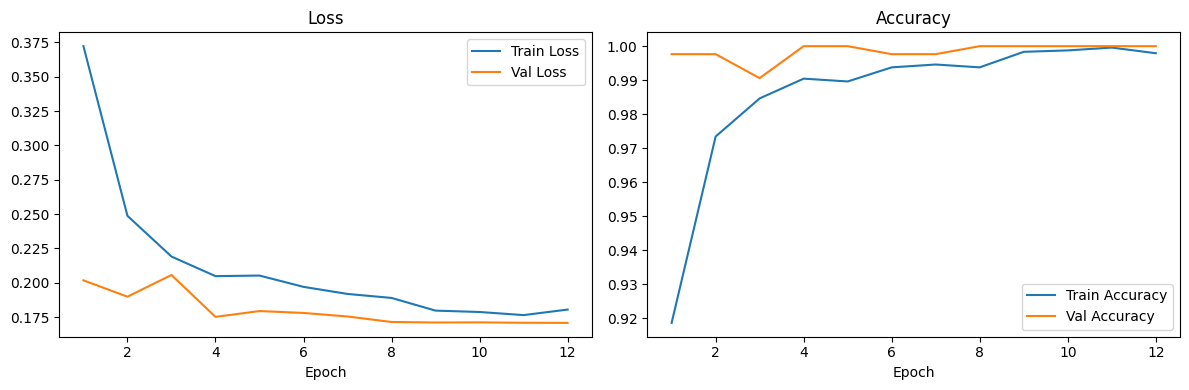

In [5]:
plot_history(history)
plt.show()


## 6. Evaluate on the Held-Out Test Set

This section measures final performance on the provided test folder and visualizes the confusion matrix.


In [6]:
test_metrics = evaluate_model(
    model=model,
    dataset=test_dataset,
    class_names=class_names,
    batch_size=config.batch_size,
    num_workers=config.num_workers,
    device=device,
)

print("Test accuracy:", round(test_metrics["accuracy"], 4))
print(json.dumps(test_metrics["classification_report"], indent=2))


Test accuracy: 0.6729
{
  "bad_back": {
    "precision": 1.0,
    "recall": 0.834319526627219,
    "f1-score": 0.9096774193548387,
    "support": 338.0
  },
  "bad_heel": {
    "precision": 0.6162790697674418,
    "recall": 0.4953271028037383,
    "f1-score": 0.5492227979274611,
    "support": 321.0
  },
  "good": {
    "precision": 0.49184149184149184,
    "recall": 0.6806451612903226,
    "f1-score": 0.571041948579161,
    "support": 310.0
  },
  "accuracy": 0.672858617131063,
  "macro avg": {
    "precision": 0.7027068538696445,
    "recall": 0.67009726357376,
    "f1-score": 0.6766473886204869,
    "support": 969.0
  },
  "weighted avg": {
    "precision": 0.7103162475399497,
    "recall": 0.672858617131063,
    "f1-score": 0.6819344581384833,
    "support": 969.0
  }
}


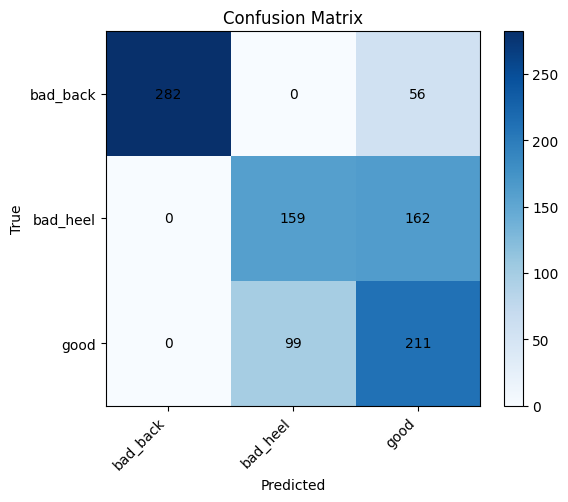

In [7]:
plot_confusion_matrix(test_metrics["confusion_matrix"], class_names)
plt.show()


## 7. Run Sample Predictions

This cell runs a few example predictions from the test set and prints the predicted class and confidence.


In [8]:
checkpoint_path = output_dir / "best_model.pt"
inference_model, inference_class_names, checkpoint_data = load_checkpoint(checkpoint_path)
inference_model = inference_model.to(device)
image_size = checkpoint_data["config"].get("image_size", 224)

sample_paths = [record.image_path for record in random.sample(test_records, k=min(6, len(test_records)))]
for path in sample_paths:
    prediction = predict_image_path(
        inference_model,
        inference_class_names,
        path,
        device=device,
        image_size=image_size,
    )
    print(path.name, "->", prediction["label_display"], f"({prediction['confidence'] * 100:.1f}%)")


Bad Heel (165).jpg -> Good (53.5%)
Good (16).jpg -> Bad Heel (97.5%)
Good (141).jpg -> Good (94.2%)
Bad Back (123).jpg -> Bad Back (61.0%)
Bad Back (23).jpg -> Bad Back (95.3%)
Good (259).jpg -> Good (93.6%)


## 8. Webcam Inference

Run the next cell after training finishes to render the webcam inline in the notebook. The overlay refuses to make a strong claim when confidence is low. Stop the cell to end the preview.


In [ ]:
import importlib
import squat_trainer.inference as inference_module

importlib.reload(inference_module)
checkpoint_path = PROJECT_ROOT / "outputs" / "resnet18_squat" / "best_model.pt"
inference_module.run_webcam_inference(
    checkpoint_path=checkpoint_path,
    camera_index=0,
    image_size=None,
    smoothing_window=7,
    confidence_threshold=0.6,
    display_mode="notebook",
)


## 9. Notes

- `good` means the frame looks like correct squat posture.
- `bad_back` means the model sees back-position issues.
- `bad_heel` means the model sees heel-position issues.
- A very high validation score with a much lower test score usually means the random validation split is easier than the real hold-out data. Trust the test set more.
- If you later collect true video clips with repetition-level labels, the next upgrade should be a temporal model over frame sequences rather than this frame-by-frame classifier.
